Coefficients: [-0.06222756]
Mean squared error: 21.23
Coefficient of determination: 0.58


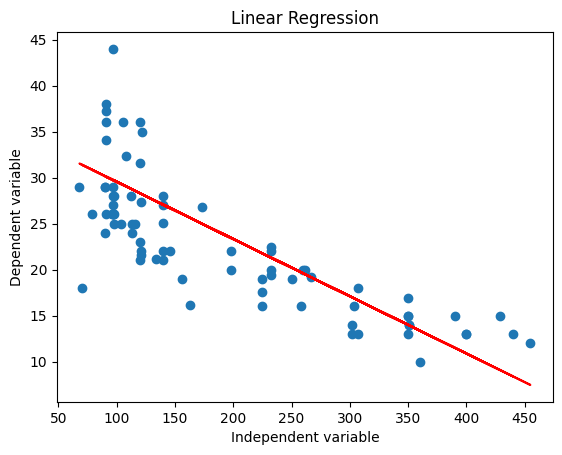

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
# Load the dataset using pandas

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower',
'Weight', 'Acceleration', 'Model Year', 'Origin', 'Car Name']
df = pd.read_csv(url, names=column_names, na_values='?',
comment='\t', sep=' ', skipinitialspace=True)
df = df.drop('Car Name', axis =1)
df = df.dropna()
# Prepare the data
X = np.array(df.Displacement).reshape(-1,1)
y = np.array(df.MPG)
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)
# Create linear regression object

model = LinearRegression()
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
print('Coefficients:', model.coef_)
print('Mean squared error: %.2f' % mean_squared_error(y_test,
y_pred))
print('Coefficient of determination: %.2f' % r2_score(y_test,
y_pred)) # 1 is perfect prediction
# Plot outputs
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.xlabel('Independent variable')
plt.ylabel('Dependent variable')
plt.title('Linear Regression')
plt.show()

Coefficients: [ 0.         -0.14767035  0.00018608]
Intercept: 43.36114932007409
Mean Squared Error: 20.6491
R² Score: 0.5954


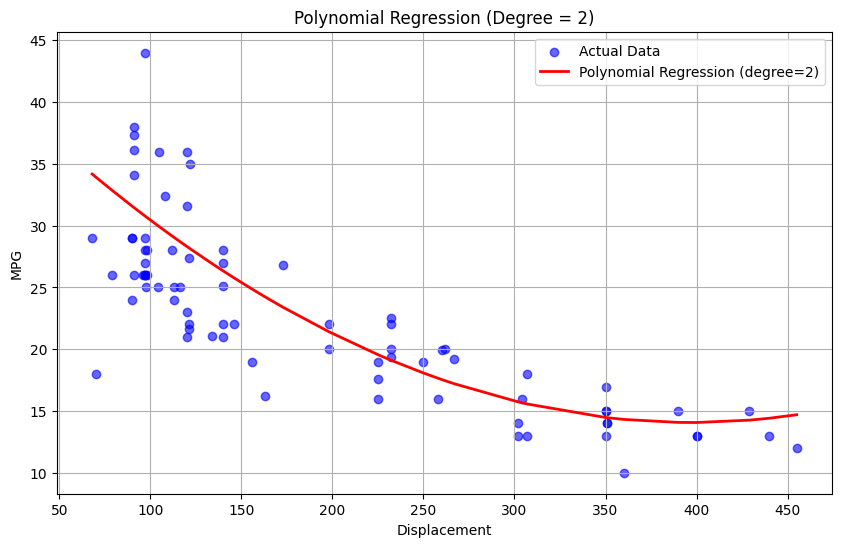

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# ====================== Load Dataset ======================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin', 'Car Name']

df = pd.read_csv(url, names=column_names, na_values='?', 
                 comment='\t', sep=' ', skipinitialspace=True)

df = df.drop('Car Name', axis=1)
df = df.dropna()

# ====================== Prepare Data ======================
X = np.array(df['Displacement']).reshape(-1, 1)
y = np.array(df['MPG'])

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ====================== Polynomial Features ======================
poly = PolynomialFeatures(degree=2)

# Important: Fit only on training data
X_train_p = poly.fit_transform(X_train)
X_test_p  = poly.transform(X_test)          # Use transform(), not fit_transform()

# ====================== Train Model ======================
model = LinearRegression()
model.fit(X_train_p, y_train)

# ====================== Predictions & Evaluation ======================
y_pred = model.predict(X_test_p)

print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Mean Squared Error: %.4f' % mean_squared_error(y_test, y_pred))
print('R² Score: %.4f' % r2_score(y_test, y_pred))

# ====================== Plot ======================
plt.figure(figsize=(10, 6))

# Sort values for smooth curve
sort_idx = np.argsort(X_test.flatten())
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X_test[sort_idx], y_pred[sort_idx], color='red', linewidth=2, 
         label='Polynomial Regression (degree=2)')

plt.xlabel('Displacement')
plt.ylabel('MPG')
plt.title('Polynomial Regression (Degree = 2)')
plt.legend()
plt.grid(True)
plt.show()

Demonstrating Linear Regression and Polynomial Regression



<>:39: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:39: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\nmshi\AppData\Local\Temp\ipykernel_6928\929517823.py:39: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  data = pd.read_csv(url, sep='\s+', names=column_names, na_values="?")


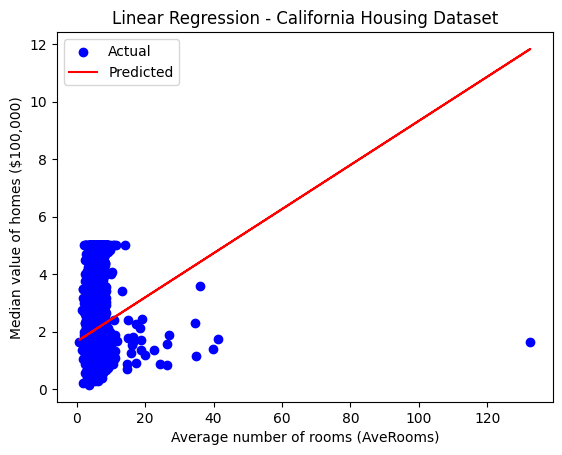

Linear Regression - California Housing Dataset
Mean Squared Error: 1.2923314440807299
R^2 Score: 0.013795337532284901


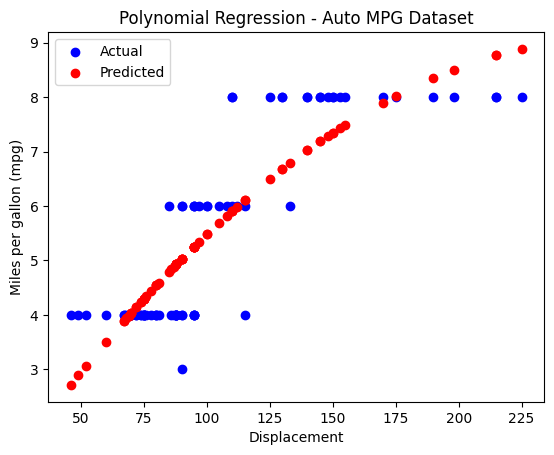

Polynomial Regression - Auto MPG Dataset
Mean Squared Error: 0.7431490557205861
R^2 Score: 0.7505650609469626


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

def linear_regression_california():
    housing = fetch_california_housing(as_frame=True)
    X = housing.data[["AveRooms"]] 
    y = housing.target 

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    plt.scatter(X_test, y_test, color="blue", label="Actual")
    plt.plot(X_test, y_pred, color="red", label="Predicted")
    plt.xlabel("Average number of rooms (AveRooms)")
    plt.ylabel("Median value of homes ($100,000)")
    plt.title("Linear Regression - California Housing Dataset")
    plt.legend()
    plt.show()

    print("Linear Regression - California Housing Dataset")
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
    print("R^2 Score:", r2_score(y_test, y_pred))


def polynomial_regression_auto_mpg():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
    column_names = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin"]
    data = pd.read_csv(url, sep='\s+', names=column_names, na_values="?")
    data = data.dropna()

    X = data["displacement"].values.reshape(-1, 1) 
    y = data["mpg"].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    poly_model = make_pipeline(PolynomialFeatures(degree=2), StandardScaler(), LinearRegression())
    poly_model.fit(X_train, y_train)

    y_pred = poly_model.predict(X_test)

    plt.scatter(X_test, y_test, color="blue", label="Actual")
    plt.scatter(X_test, y_pred, color="red", label="Predicted")
    plt.xlabel("Displacement")
    plt.ylabel("Miles per gallon (mpg)")
    plt.title("Polynomial Regression - Auto MPG Dataset")
    plt.legend()
    plt.show()

    print("Polynomial Regression - Auto MPG Dataset")
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
    print("R^2 Score:", r2_score(y_test, y_pred))


if __name__ == "__main__":
    print("Demonstrating Linear Regression and Polynomial Regression\n")
    linear_regression_california()
    polynomial_regression_auto_mpg()